# Chapter 5 — IoT Device Technologies
## Embedded Hardware, Power Management, Energy Harvesting, and RTOS

This notebook accompanies Chapter 5 of *Fundamentals of the Internet of Things* (revised draft v0.3, 10 August 2026).

The exercises are deliberately introductory. They use **synthetic parameters** so that every reader can run them in Google Colab without hardware, cloud credentials, or external datasets. The numerical values are not benchmarks for a named MCU, battery, RTOS, radio, or solar harvester.

### Learning goals
By the end of the notebook you should be able to:
1. convert an IoT device state machine into a first-order charge/current and battery-life estimate;
2. see the timing/energy trade-off between periodic polling and event-driven execution;
3. simulate finite energy storage under variable solar harvesting and identify explicit service outages;
4. compute a fixed-priority task's worst-case response time and see how an unbounded critical section can break a deadline.

### Reproducibility
- Exercise 5.1 is deterministic.
- Exercise 5.2 uses seed **42** for event arrivals and seed **7** for event-response latency. Event-response latency is sampled from Normal(mean = 0.55 ms, std = 0.12 ms), clipped below at 0.25 ms.
- Exercise 5.3 uses seed **2026** for cloud attenuation. Hourly cloud factors are sampled from Normal(mean = 0.82, std = 0.18), clipped to [0.35, 1.0], and held constant within each hour.
- Exercise 5.4 is a deterministic analytical model (fixed-priority response-time analysis); no random sampling is used.

**Recommended workflow:** run the notebook from top to bottom once, reproduce the chapter figures and tables, then change one parameter at a time.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

---
# Exercise 5.1 — From a Device State Machine to a Battery-Life Estimate

### Background
A small outdoor monitoring node wakes periodically. One cycle consists of sensor warm-up, sampling, local processing, one communication burst, and sleep.

The goal is **not** to model a specific radio or battery. The goal is to learn the accounting method:

\[
I_{avg}=\frac{\sum_k I_k t_k}{T}
\]

Here, `current × time` is **charge**, not energy. Battery capacity in mAh is also a charge capacity. If all states are evaluated at approximately the same battery-side voltage, charge shares are proportional to energy shares; otherwise an energy model must include voltage and conversion efficiency.

In [2]:
cycle_s = 300.0  # five minutes
usable_fraction = 0.80
battery_capacity_mAh = 2400.0

states = pd.DataFrame({
    "state": ["Sensor warm-up", "Sample", "Compute", "Transmit", "Sleep"],
    "duration_s": [2.5, 0.2, 0.3, 0.8, 296.2],
    "current_mA": [12.0, 8.0, 25.0, 80.0, 0.02],
})

states["charge_mAs"] = states["duration_s"] * states["current_mA"]
states["charge_share_pct"] = 100 * states["charge_mAs"] / states["charge_mAs"].sum()

avg_current_mA = states["charge_mAs"].sum() / cycle_s
usable_capacity_mAh = usable_fraction * battery_capacity_mAh
life_days = usable_capacity_mAh / avg_current_mA / 24

print(f"Average current for the 5-minute cycle: {avg_current_mA:.3f} mA")
print(f"Idealised battery life: {life_days:.1f} days")
states[["state", "duration_s", "current_mA", "charge_share_pct"]]

Average current for the 5-minute cycle: 0.363 mA
Idealised battery life: 220.1 days


,state,duration_s,current_mA,charge_share_pct
0,Sensor warm-up,2.5,12.00,27.517
1,Sample,0.2,8.00,1.468
2,Compute,0.3,25.00,6.879
3,Transmit,0.8,80.00,58.703
4,Sleep,296.2,0.02,5.434


### Sensitivity to measurement interval
We now keep the active work per cycle unchanged and vary only the time spent sleeping. This is a deliberately simple model: no self-discharge, ageing, temperature, regulator loss, retries, or voltage cut-off are included.

In [3]:
active = states.iloc[:4].copy()
active_duration_s = active["duration_s"].sum()
active_charge_mAs = active["charge_mAs"].sum()
sleep_current_mA = 0.02

intervals_min = np.array([1, 2, 5, 10, 15, 30, 60], dtype=float)
rows = []

for interval_min in intervals_min:
    T = interval_min * 60
    sleep_s = max(T - active_duration_s, 0)
    charge_mAs = active_charge_mAs + sleep_s * sleep_current_mA
    i_avg = charge_mAs / T
    days = usable_capacity_mAh / i_avg / 24
    rows.append((interval_min, i_avg, days))

battery_results = pd.DataFrame(rows, columns=["interval_min", "avg_current_mA", "ideal_life_days"])
battery_results

,interval_min,avg_current_mA,ideal_life_days
0,1.0,1.737,46.055
1,2.0,0.879,91.061
2,5.0,0.363,220.135
3,10.0,0.192,417.304
4,15.0,0.134,594.923
5,30.0,0.077,1035.792
6,60.0,0.049,1645.489


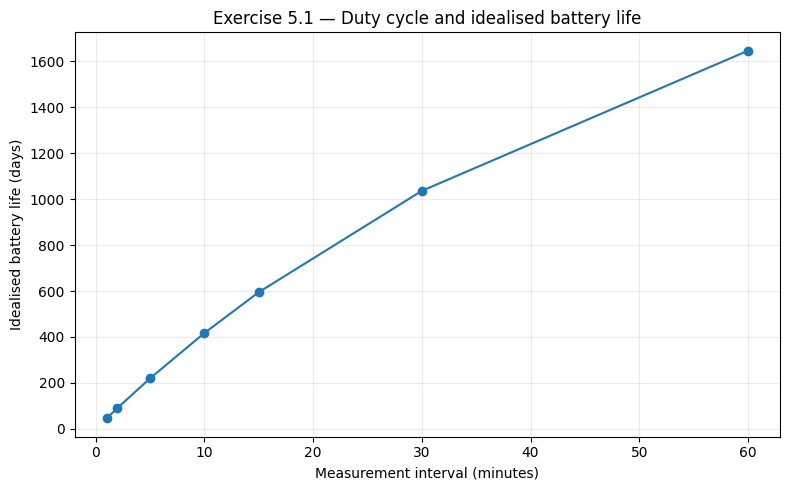

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(battery_results["interval_min"], battery_results["ideal_life_days"], marker="o")
plt.xlabel("Measurement interval (minutes)")
plt.ylabel("Idealised battery life (days)")
plt.title("Exercise 5.1 — Duty cycle and idealised battery life")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig_5_1_battery_life.png", dpi=180)
plt.show()

### Interpretation
The five-minute configuration gives about **0.363 mA** average current and about **220 days** of idealised life. The transmission burst contributes the largest **charge share** in this parameter set.

This average-current calculation is a useful **first-order screening model**, not a complete battery model. The curve shows diminishing returns at long intervals because the sleep current remains present all the time. In a multi-year deployment, self-discharge, temperature, ageing, regulator efficiency, voltage cut-off, retries, and board leakage matter.

If different power rails or converter efficiencies must be compared, move from charge accounting to an energy model using `voltage × current × time`.

### Challenge
1. Add a 2% probability of one retransmission per cycle.
2. Compare sleep currents of 0.02 mA and 0.10 mA.
3. Find the interval beyond which further reductions in sampling frequency provide little benefit.

---
# Exercise 5.2 — Polling versus Event-Driven Task Execution

### Background
An IoT device reacts to asynchronous events: motion, a button, a packet arrival, an alarm threshold, and so on. A polling design wakes periodically to check whether anything happened. An event-driven design blocks and wakes when hardware/interrupt logic signals work.

This is a conceptual timing model, **not** a benchmark of a particular RTOS. Event-driven execution can also be implemented in carefully designed bare-metal firmware.

The 120 s run and the five polling intervals (10, 50, 100, 250, 500 ms) are chosen so that every interval divides the run length exactly. The number of polling checks is therefore an exact integer count over the half-open window `[0, T)` with no boundary ambiguity.


In [5]:
rng = np.random.default_rng(42)
duration_s = 120.0
event_rate_hz = 0.8

# Poisson arrival process generated from exponential inter-arrival times.
t = 0.0
events = []
while True:
    t += rng.exponential(1 / event_rate_hz)
    if t >= duration_s:
        break
    events.append(t)

events = np.array(events)
expected_events = event_rate_hz * duration_s
print(f"Expected event count λT: {expected_events:.1f}")
print(f"Fixed-seed realisation (seed 42): {len(events)} events")

Expected event count λT: 96.0
Fixed-seed realisation (seed 42): 102 events


In [6]:
poll_intervals_ms = [10, 50, 100, 250, 500]
check_active_ms = 0.35
process_active_ms = 3.0
event_active_overhead_ms = 0.15
duration_ms = int(round(duration_s * 1000))  # 120000 ms

rows = []
for p_ms in poll_intervals_ms:
    p_s = p_ms / 1000.0
    detect_t = np.ceil(events / p_s) * p_s
    latency_ms = (detect_t - events) * 1000
    # Integer-ms arithmetic: every interval divides duration_ms exactly,
    # so this is an unambiguous count of checks over [0, T).
    checks = duration_ms // p_ms
    active_ms = checks * check_active_ms + len(events) * process_active_ms
    rows.append({
        "policy": f"Poll {p_ms} ms",
        "interval_ms": p_ms,
        "wakeups_or_checks": checks,
        "mean_latency_ms": latency_ms.mean(),
        "p95_latency_ms": np.percentile(latency_ms, 95),
        "cpu_active_pct": 100 * active_ms / (duration_s * 1000),
    })

# Event-driven path. Response latency and active CPU overhead are intentionally
# modelled as separate quantities. Latency seed = 7.
# Model: response latency ~ Normal(mean=0.55 ms, std=0.12 ms), clipped below at 0.25 ms.
rng_event = np.random.default_rng(7)
event_latency_ms = np.clip(
    rng_event.normal(0.55, 0.12, size=len(events)),
    0.25,
    None,
)
event_active_ms = len(events) * (process_active_ms + event_active_overhead_ms)
rows.append({
    "policy": "Event driven",
    "interval_ms": np.nan,
    "wakeups_or_checks": len(events),
    "mean_latency_ms": event_latency_ms.mean(),
    "p95_latency_ms": np.percentile(event_latency_ms, 95),
    "cpu_active_pct": 100 * event_active_ms / (duration_s * 1000),
})

event_results = pd.DataFrame(rows)
print("Event-driven latency model: Normal(mean=0.55 ms, std=0.12 ms), clipped below at 0.25 ms, seed 7.")
event_results

Event-driven latency model: Normal(mean=0.55 ms, std=0.12 ms), clipped below at 0.25 ms, seed 7.


,policy,interval_ms,wakeups_or_checks,mean_latency_ms,p95_latency_ms,cpu_active_pct
0,Poll 10 ms,10.0,12000,5.043,9.500,3.755
1,Poll 50 ms,50.0,2400,23.573,44.793,0.955
2,Poll 100 ms,100.0,1200,51.024,91.606,0.605
3,Poll 250 ms,250.0,480,121.612,233.320,0.395
4,Poll 500 ms,500.0,240,249.063,468.837,0.325
5,Event driven,NaN,102,0.528,0.700,0.268


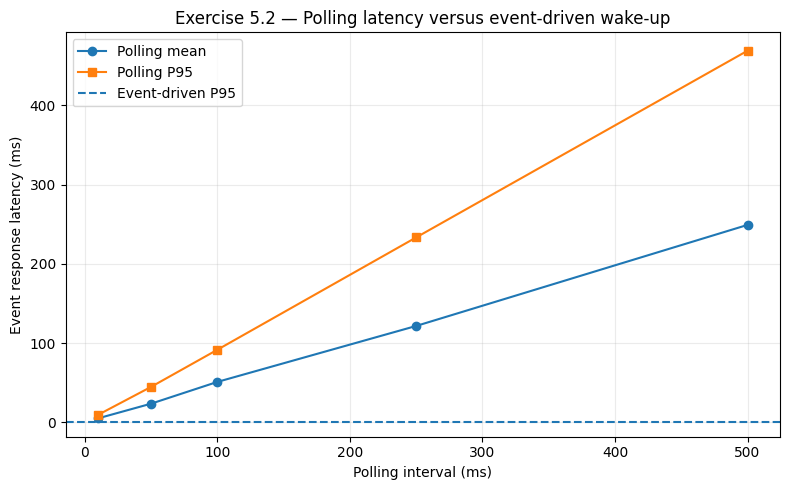

In [7]:
poll_only = event_results[event_results["policy"].str.startswith("Poll")]
event_p95 = event_results.loc[event_results["policy"] == "Event driven", "p95_latency_ms"].iloc[0]

plt.figure(figsize=(8, 5))
plt.plot(poll_only["interval_ms"], poll_only["mean_latency_ms"], marker="o", label="Polling mean")
plt.plot(poll_only["interval_ms"], poll_only["p95_latency_ms"], marker="s", label="Polling P95")
plt.axhline(event_p95, linestyle="--", label="Event-driven P95")
plt.xlabel("Polling interval (ms)")
plt.ylabel("Event response latency (ms)")
plt.title("Exercise 5.2 — Polling latency versus event-driven wake-up")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig_5_2_polling_event.png", dpi=180)
plt.show()

### Interpretation
Short polling intervals improve responsiveness but create many checks. Long intervals reduce checks but delay events. In this synthetic trace, an event-driven path needs only one wake-up per event and avoids waiting for the next periodic poll.

The two event-driven quantities are deliberately separate:

- response latency is sampled from Normal(mean = 0.55 ms, std = 0.12 ms), clipped below at 0.25 ms, seed 7, producing mean ≈ **0.528 ms** and P95 ≈ **0.700 ms**;
- CPU active time uses **3.0 ms processing + 0.15 ms active scheduling/wake overhead** per event.

For 102 events, active time is `102 × (3.0 + 0.15) = 321.3 ms`, which is **0.268%** of 120 s. The polling checks in the table above are exact counts over `[0, 120 s)` — for example, the 10 ms policy performs exactly `120000 / 10 = 12000` checks, not 12001.

This does **not** imply zero-latency interrupts or that an RTOS is always better. Real latency depends on priorities, critical sections, disabled-interrupt time, clock/power state, and overload.

### Challenge
1. Increase the event rate until a bounded queue overflows.
2. Add one high-priority alarm stream and one normal stream.
3. Decide which events can be coalesced and which must be preserved individually.


---
# Exercise 5.3 — Solar Energy Harvesting and Energy-Neutral Operation

### Background
A remote node has a small solar harvester and rechargeable storage. The input changes with daylight and cloud attenuation. We ask whether several requested average loads can be served over one synthetic week.

A clipped storage equation alone is not enough: **SoC = 0 must mean that some requested service cannot be delivered** when instantaneous harvest is also insufficient. The revised simulation therefore tracks both stored energy and unserved load, and separately reports the fraction of requested energy actually served.


In [8]:
rng = np.random.default_rng(2026)
dt_min = 10
steps = 7 * 24 * 60 // dt_min
hours_from_start = np.arange(steps) * dt_min / 60
hour_of_day = hours_from_start % 24

# Smooth daylight profile from 06:00 to 18:00.
daylight = np.where(
    (hour_of_day >= 6) & (hour_of_day <= 18),
    np.sin(np.pi * (hour_of_day - 6) / 12),
    0.0,
)

# Hourly cloud attenuation: Normal(mean=0.82, std=0.18), clipped to [0.35, 1.0],
# resampled once per hour and held constant within the hour. Fixed seed for reproducibility.
cloud_hourly = np.clip(rng.normal(0.82, 0.18, size=7 * 24), 0.35, 1.0)
cloud = np.repeat(cloud_hourly, 60 // dt_min)[:steps]

harvest_mW = 22.0 * daylight * cloud
avg_harvest_mW = harvest_mW.mean()
daily_harvest_Wh = harvest_mW.sum() * (dt_min / 60) / 1000 / 7

print("Cloud attenuation model: hourly factor ~ Normal(mean=0.82, std=0.18), clipped to [0.35, 1.0], seed 2026.")
print(f"Average harvested power: {avg_harvest_mW:.3f} mW")
print(f"Average harvested energy per day: {daily_harvest_Wh:.3f} Wh/day")

Cloud attenuation model: hourly factor ~ Normal(mean=0.82, std=0.18), clipped to [0.35, 1.0], seed 2026.
Average harvested power: 5.543 mW
Average harvested energy per day: 0.133 Wh/day


In [9]:
capacity_Wh = 0.5
initial_Wh = 0.60 * capacity_Wh
loads_mW = [3.0, 5.0, 8.0]
dt_h = dt_min / 60

trajectories = {}   # SoC trajectories INCLUDING the t=0 initial state (length steps+1)
outage_masks = {}   # one flag per simulated interval (length steps)
summary = []

for load_mW in loads_mW:
    e = initial_Wh
    soc = [100 * e / capacity_Wh]   # t = 0, before any harvesting/consumption
    outage = []
    first_failure_h = None
    unserved_Wh = 0.0
    requested_step_Wh = load_mW * dt_h / 1000

    for i, p_h in enumerate(harvest_mW):
        # Energy physically available during this time step.
        available_Wh = e + p_h * dt_h / 1000

        # Serve no more energy than is available. Any deficit is a service outage.
        served_Wh = min(requested_step_Wh, available_Wh)
        unmet_Wh = requested_step_Wh - served_Wh
        is_outage = unmet_Wh > 1e-15

        if is_outage and first_failure_h is None:
            first_failure_h = i * dt_h
        unserved_Wh += unmet_Wh
        outage.append(is_outage)

        # Remaining energy is stored, but storage cannot exceed capacity.
        e = min(capacity_Wh, max(0.0, available_Wh - served_Wh))
        soc.append(100 * e / capacity_Wh)

    soc = np.array(soc)                    # length steps + 1 (includes t = 0)
    outage = np.array(outage, dtype=bool)  # length steps
    trajectories[load_mW] = soc
    outage_masks[load_mW] = outage

    requested_total_Wh = requested_step_Wh * steps
    served_fraction = 1 - unserved_Wh / requested_total_Wh
    summary.append({
        "requested_load_mW": load_mW,
        "final_soc_pct": soc[-1],
        "minimum_soc_pct": soc.min(),
        "first_service_failure_h": first_failure_h,
        "outage_affected_timesteps_h": outage.sum() * dt_h,
        "unserved_energy_Wh": unserved_Wh,
        "requested_energy_served_pct": 100 * served_fraction,
    })

harvest_results = pd.DataFrame(summary)
harvest_results

,requested_load_mW,final_soc_pct,minimum_soc_pct,first_service_failure_h,outage_affected_timesteps_h,unserved_energy_Wh,requested_energy_served_pct
0,3.0,96.292,56.144,NaN,0.000,0.000,100.000
1,5.0,78.239,53.364,NaN,0.000,0.000,100.000
2,8.0,0.000,0.000,122.5,15.833,0.113,91.607


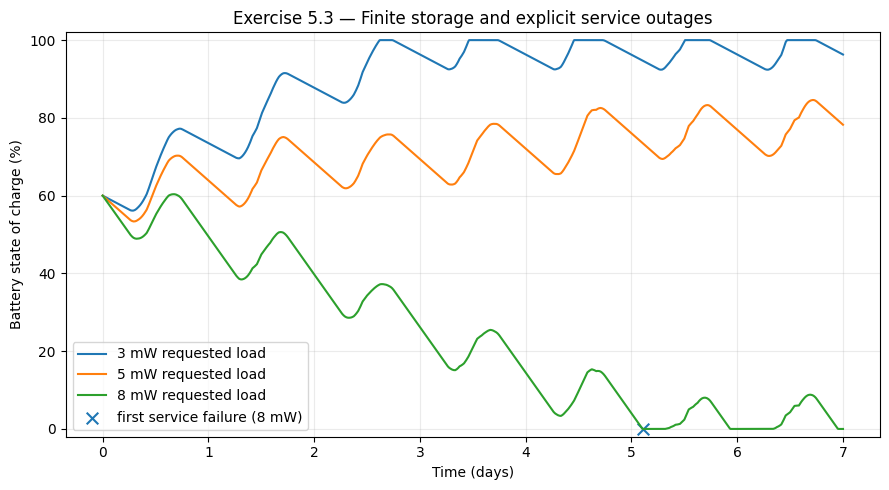

In [10]:
t_soc_days = np.arange(steps + 1) * dt_min / 60 / 24  # matches the t=0-inclusive soc arrays

plt.figure(figsize=(9, 5))
for load_mW, soc in trajectories.items():
    line, = plt.plot(t_soc_days, soc, label=f"{load_mW:.0f} mW requested load")
    mask = outage_masks[load_mW]
    if mask.any():
        first_interval = np.flatnonzero(mask)[0]   # index of the first affected interval
        marker_idx = first_interval + 1             # SoC sample right after that interval
        plt.scatter(t_soc_days[marker_idx], soc[marker_idx], marker="x", s=70,
                    label=f"first service failure ({load_mW:.0f} mW)")

plt.xlabel("Time (days)")
plt.ylabel("Battery state of charge (%)")
plt.title("Exercise 5.3 — Finite storage and explicit service outages")
plt.ylim(-2, 102)
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig_5_3_energy_harvesting.png", dpi=180)
plt.show()

### Interpretation
The weekly average solar input is about **5.54 mW**, but the midday peak is much larger. The 3 mW and 5 mW configurations do not deplete storage in this particular week. The 8 mW configuration experiences its first service failure after about **122.5 h** and accumulates about **15.8 h** of outage-affected time steps, corresponding to roughly **0.113 Wh** of unserved energy — about **91.6%** of the requested energy is still served over the week.

A one-week non-depletion result is **not** evidence of year-round energy-neutral operation. The lesson is that a peak-power comparison is not enough: energy harvesting is a **time-series, storage, and availability** problem. A production model would use measured irradiance, panel orientation, conversion efficiency, temperature, ageing, restart/brownout behaviour, and state-dependent device load.

A simple adaptive policy can use hysteresis: enter conservation mode below 40% SoC and return to normal mode only above 60% SoC. The lower mode may reduce sampling or reporting frequency, trading data yield for a lower probability of outage.

### Challenge
1. Implement the 40%/60% hysteretic conservation policy.
2. Compare data yield, minimum SoC, and outage time.
3. Repeat the experiment with two consecutive “bad-weather” days whose harvest is reduced by 70%.


---
# Exercise 5.4 — Fixed-Priority Scheduling, Priority Inversion, and Response Time

### Background
Section 5.2 describes a wearable motion node built from an ISR, an AcquisitionTask, an AlarmTask, and a TelemetryTask, and states explicitly that a design does not meet a response deadline just because the tasks exist: the timing must be analysed or measured. This exercise makes that analysis concrete for a small three-task, fixed-priority design and connects it to the 10 ms response deadline used in the wearable fall-detector scenario. It is slightly more analytical than Exercises 5.1–5.3 and can be treated as an optional extension on a first reading.


In [11]:
# Fixed-priority response-time analysis (fixed-point iteration).
# For a task with worst-case execution time C, worst-case blocking time B, and
# a set of strictly higher-priority tasks (each with its own execution time
# C_j and minimum period/inter-arrival time T_j):
#
#     R = C + B + sum_j ceil(R / T_j) * C_j
#
# This is the classical fixed-priority response-time analysis of Joseph and
# Pandya (1986), built on Liu and Layland's foundational fixed-priority
# scheduling model, with a blocking term for shared resources following Sha,
# Rajkumar, and Lehoczky's priority-ceiling analysis.

def response_time(C, B, higher_priority_tasks, max_iter=200):
    """higher_priority_tasks: list of (C_j, T_j) for strictly higher-priority tasks."""
    R = C + B
    for _ in range(max_iter):
        interference = sum(np.ceil(R / T_j) * C_j for C_j, T_j in higher_priority_tasks)
        R_new = C + B + interference
        if np.isclose(R_new, R):
            return R_new
        if R_new > 50 * (C + B + 1):
            return np.inf  # diverging: task set is not schedulable at this priority
        R = R_new
    return R

# Task parameters (all times in ms)
C_alarm, T_alarm_min = 2.0, 500.0     # sporadic, minimum inter-arrival
C_acq,   T_acq       = 0.4, 10.0      # periodic
C_tel,   T_tel       = 15.0, 200.0    # periodic
B_baseline = 1.5                       # TelemetryTask's mutex-protected diagnostic section
deadline_alarm_ms = 10.0

# We assume the shared mutex uses a priority-ceiling protocol, so its ceiling
# equals AlarmTask's priority (the highest priority task that can lock it).
# Under this protocol AlarmTask can be blocked by at most one lower-priority
# critical section (the analysis below). The same ceiling also means
# AcquisitionTask -- which never touches the mutex -- can experience the same
# bounded "push-through" blocking while TelemetryTask holds it, because the
# mutex's ceiling is at or above AcquisitionTask's own priority. Both tasks
# therefore carry the same B = 1.5 ms blocking term in this model.
R_alarm_baseline = response_time(C_alarm, B_baseline, higher_priority_tasks=[])
R_acq_baseline = response_time(C_acq, B_baseline, higher_priority_tasks=[(C_alarm, T_alarm_min)])

print(f"AlarmTask worst-case response time: {R_alarm_baseline:.2f} ms (deadline {deadline_alarm_ms:.0f} ms)")
print(f"AcquisitionTask worst-case response time: {R_acq_baseline:.2f} ms (period {T_acq:.0f} ms)")

rta_results = pd.DataFrame([
    {"task": "AlarmTask", "priority": "Highest", "wcet_ms": C_alarm, "blocking_ms": B_baseline,
     "worst_case_response_ms": R_alarm_baseline, "deadline_ms": deadline_alarm_ms,
     "deadline_met": bool(R_alarm_baseline <= deadline_alarm_ms)},
    {"task": "AcquisitionTask", "priority": "Middle", "wcet_ms": C_acq, "blocking_ms": B_baseline,
     "worst_case_response_ms": R_acq_baseline, "deadline_ms": T_acq,
     "deadline_met": bool(R_acq_baseline <= T_acq)},
])
rta_results

AlarmTask worst-case response time: 3.50 ms (deadline 10 ms)
AcquisitionTask worst-case response time: 3.90 ms (period 10 ms)


,task,priority,wcet_ms,blocking_ms,worst_case_response_ms,deadline_ms,deadline_met
0,AlarmTask,Highest,2.0,1.5,3.5,10.0,True
1,AcquisitionTask,Middle,0.4,1.5,3.9,10.0,True


Analytical deadline limit: B = 8.00 ms
First violating point on the 0.25 ms sampling grid: B = 8.25 ms


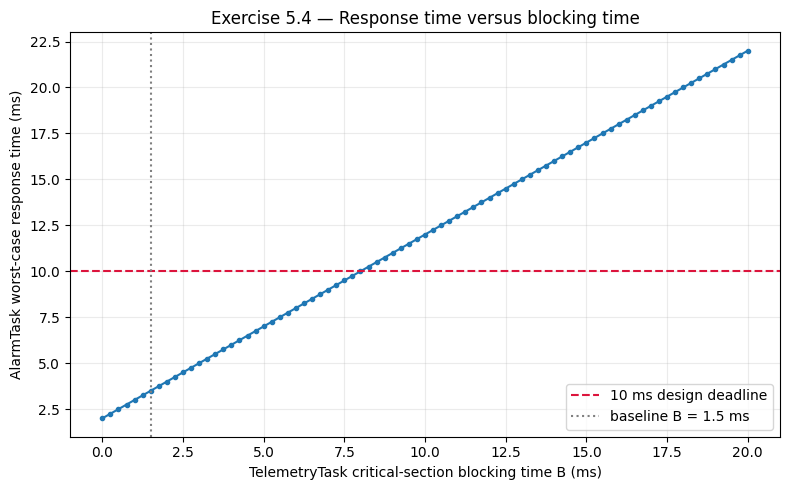

In [12]:
# Sweep the TelemetryTask blocking time to find where AlarmTask's deadline breaks.
B_values_ms = np.linspace(0, 20, 81)
R_alarm_sweep = np.array([response_time(C_alarm, B, higher_priority_tasks=[]) for B in B_values_ms])

# Analytical threshold: R = C_alarm + B = deadline  =>  B = deadline - C_alarm
analytical_threshold_ms = deadline_alarm_ms - C_alarm

over_deadline = B_values_ms[R_alarm_sweep > deadline_alarm_ms]
first_sampled_violation_ms = over_deadline.min() if len(over_deadline) else None

print(f"Analytical deadline limit: B = {analytical_threshold_ms:.2f} ms")
print(f"First violating point on the {B_values_ms[1]-B_values_ms[0]:.2f} ms sampling grid: B = {first_sampled_violation_ms:.2f} ms")

plt.figure(figsize=(8, 5))
plt.plot(B_values_ms, R_alarm_sweep, marker="o", markersize=3)
plt.axhline(deadline_alarm_ms, color="crimson", linestyle="--", label="10 ms design deadline")
plt.axvline(B_baseline, color="gray", linestyle=":", label=f"baseline B = {B_baseline:.1f} ms")
plt.xlabel("TelemetryTask critical-section blocking time B (ms)")
plt.ylabel("AlarmTask worst-case response time (ms)")
plt.title("Exercise 5.4 \u2014 Response time versus blocking time")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig_5_4_response_time.png", dpi=180)
plt.show()

### Interpretation
With the baseline 1.5 ms critical section, AlarmTask's worst-case response time is `C + B = 3.5 ms`, comfortably inside its 10 ms deadline. Because the shared mutex's priority ceiling equals AlarmTask's own priority, AcquisitionTask can also experience the same bounded 1.5 ms "push-through" blocking while TelemetryTask holds that mutex, even though AcquisitionTask never accesses it directly. Its worst-case response time is therefore `0.4 + 1.5 + \lceil R/500\rceil \times 2.0 = 3.9` ms, still well inside its 10 ms period. Both tasks meet their deadlines, but for a consistent reason: the priority-ceiling protocol bounds *every* task at or below the ceiling to at most one lower-priority critical section of blocking, not zero.

The sweep shows why that blocking time is worth bounding deliberately rather than left as an accident of implementation. AlarmTask's deadline is exceeded analytically once `B` exceeds `10.0 - 2.0 = 8.00` ms; on the sweep's 0.25 ms sampling grid, the first point actually flagged as a violation is `B = 8.25` ms, one grid step past the true threshold. This is the practical meaning of the priority-inversion risk introduced in Section 5.2: an unbounded critical section in a low-priority task can silently break a high-priority deadline, and under a priority-ceiling protocol it can also delay tasks that never touch the shared resource at all.

This exercise uses a standard analytical scheduling model, not a live RTOS trace: it excludes context-switch overhead, cache effects, and interrupt jitter, and it does not prove that any particular kernel meets the deadline in practice. It shows why worst-case blocking time is a design parameter to bound deliberately --- through a priority-ceiling or priority-inheritance mutex, or a hard limit on critical-section length --- rather than an accident of implementation.

### Challenge
1. Recompute both response times if TelemetryTask's critical section grows to 5 ms, and check whether AcquisitionTask still meets its period.
2. Give AcquisitionTask a shorter 5 ms period and check whether its own worst-case response time still fits inside it.
3. Replace the 500 ms sporadic minimum inter-arrival with a burst model (for example, two fall-candidate events 50 ms apart) and discuss how AlarmTask's own interference term would need to change if it were not the highest-priority task.


---
# Final reflection

The four exercises use deliberately different abstractions:

- **Exercise 5.1:** a *state machine* becomes a charge/current and first-order battery-life budget;
- **Exercise 5.2:** an *execution model* becomes a response-latency and wake-up budget;
- **Exercise 5.3:** an *energy source* becomes a time-varying storage and service-availability problem;
- **Exercise 5.4:** a *task set* becomes a worst-case response-time and blocking-time budget.

Before moving to gateways, sensors, and communication protocols, try to describe one real IoT product using these four views. Which operating states dominate charge or energy? Which events need bounded response time? Which task would miss its deadline first if a lower-priority task misbehaved? Which assumptions would you need to measure on real hardware?
